# Electricity Cost Prediction Dataset

---

## Sobre o Conjunto de Dados

Este conjunto de dados, intitulado "Powering Predictions: Unveiling the Dynamics of Electricity Costs in Modern Infrastructure" (Fortalecendo Previsões: Revelando a Dinâmica dos Custos de Eletricidade em Infraestruturas Modernas), fornece uma coleção realista e abrangente de 10.000 pontos de dados projetados para previsão de custos de eletricidade. Ele abrange uma variedade de fatores que influenciam o consumo e as despesas de energia em diferentes tipos de locais. O conjunto de dados inclui as seguintes colunas principais:

- ***Site Area (square meters)*** Área do Local (metros quadrados): Representa o tamanho físico do imóvel, um dos principais impulsionadores das necessidades energéticas.
- ***Structure Type*** Tipo de Estrutura: Categoriza o imóvel em "Residencial", "Comercial", "Uso Misto" ou "Industrial", refletindo diversos padrões operacionais e de consumo.
- ***Water Consumption (liters/day)*** Consumo de Água (litros/dia): Um indicador indireto do uso de energia, especialmente para aquecimento e bombeamento de água.
- ***Recycling Rate (%)*** Taxa de Reciclagem (%): Sugere a consciência ambiental e as potenciais práticas de eficiência energética do local.
- ***Utilisation Rate (%)*** Taxa de Utilização (%): Indica a intensidade operacional e o uso da capacidade, impactando diretamente a demanda de energia.
- ***Air Quality Index (AQI)*** Índice de Qualidade do Ar (IQA): Pode influenciar o consumo de energia por meio do uso do sistema HVAC para manter a qualidade do ar interno.
- ***Issue Resolution Time (hours)*** Tempo de Resolução de Problemas (horas): Um indicador da eficiência operacional; tempos de resolução mais longos podem estar relacionados ao desperdício de energia.
- ***Resident Count (number of people)*** Contagem de Residentes (número de pessoas): Um fator significativo para propriedades residenciais e de uso misto, afetando diretamente o consumo de eletricidade.
- ***Electricity Cost (USD/month)*** Custo de Eletricidade (USD/mês): A variável-alvo, que representa o gasto mensal com eletricidade, influenciada por todos os outros parâmetros.

Cada ponto de dados foi cuidadosamente gerado para garantir realismo e credibilidade, com valores dentro das faixas nominais e esperadas para cada coluna respectiva. As relações entre colunas foram modeladas para refletir cenários do mundo real, tornando este conjunto de dados adequado para o desenvolvimento e teste de modelos robustos de previsão de custos de eletricidade.

Link dataset Kaggle: https://www.kaggle.com/datasets/shalmamuji/electricity-cost-prediction-dataset/data?select=electricity_cost_dataset.csv

---
## Objetivos:

Utilizar a base de dados para exercicitar praticas de manipulação de dados, tratamento de dados, modelos de ML para regressão, metricas de desempenho do Modelo entre outras melhorias.

- Análise Exploratória
- Visualizações Gráficas
- Tratamento dos Dados (se necessário)
    - Pipeline de Pré-Processamento
- Implementação de Modelos de Regressão para previsão da Variável "electricity cost"


---
## 1 - Importação das bibliotecas e Análise Exploratória

In [3]:
#Bibliotecas para manipulação e visualizações gráficas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:
#Leitura do csv e criação do DF
df_original = pd.read_csv('electricity_cost_dataset.csv')

#Leitura do head do DF
df_original.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [ ]:
#Informações do DF (tamanho, tipo de variável, qtd de colunas, valores nulos e etc)
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


- ***structure type***: É uma coluna categorica, que possivelmente tem grande influência na nossa variável alvo. Sendo necessario tratamento posterior.

In [12]:
#Describe, para verificar de forma inicial a distribuição dos dados
df_original.describe()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2757.775100,3494.057100,49.598000,64.842200,99.468600,36.402600,85.573100,2837.845000
std,1293.059959,2076.181117,23.430141,20.432965,58.014526,20.623905,107.876179,1106.997441
min,501.000000,1000.000000,10.000000,30.000000,0.000000,1.000000,0.000000,500.000000
25%,1624.000000,1779.000000,29.750000,47.000000,49.000000,19.000000,0.000000,1954.000000
50%,2773.500000,3047.500000,49.000000,65.000000,100.000000,36.000000,39.000000,2760.000000
75%,3874.000000,4811.000000,70.000000,83.000000,150.000000,54.000000,142.000000,3632.000000
max,5000.000000,10894.000000,90.000000,100.000000,200.000000,72.000000,489.000000,6446.000000


- ***air quality index***: Valor minimo em 0.0 podendo ser dados incorretos .
- ***resident count***: Valor minimo em 0.0, mas acredito que aqui seja mais comum termos residencias vazias ou empresas que não façam a conta de "funcionarios".

In [14]:
#Verifica linhas duplicadas
df_original.duplicated().sum()

np.int64(0)

In [15]:
#Verifica (novamente) linhas nulas ou vazias
df_original.isnull().sum()

site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

In [16]:
df_original.isna().sum()

site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

---
## 2 - Exploração Gráfica

In [19]:
#Definir variável para colunas númericas
numeric_columns = df_original.select_dtypes(['int64', 'float64'])

#Verifica colunas adicionadas ao novo DF
numeric_columns.head()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,2519.0,69,52,188,1,72,1420.0
1,4272,2324.0,50,76,165,65,261,3298.0
2,3592,2701.0,20,94,198,39,117,3115.0
3,966,1000.0,13,60,74,3,35,1575.0
4,4926,5990.0,23,65,32,57,185,4301.0


### 2.1 - Boxplot

Objetivo: 
- Identificar a distribuição dos dados
- Detectar outliers
- Intervalo interquartil (IQR)
- Valores mínimos e máximos

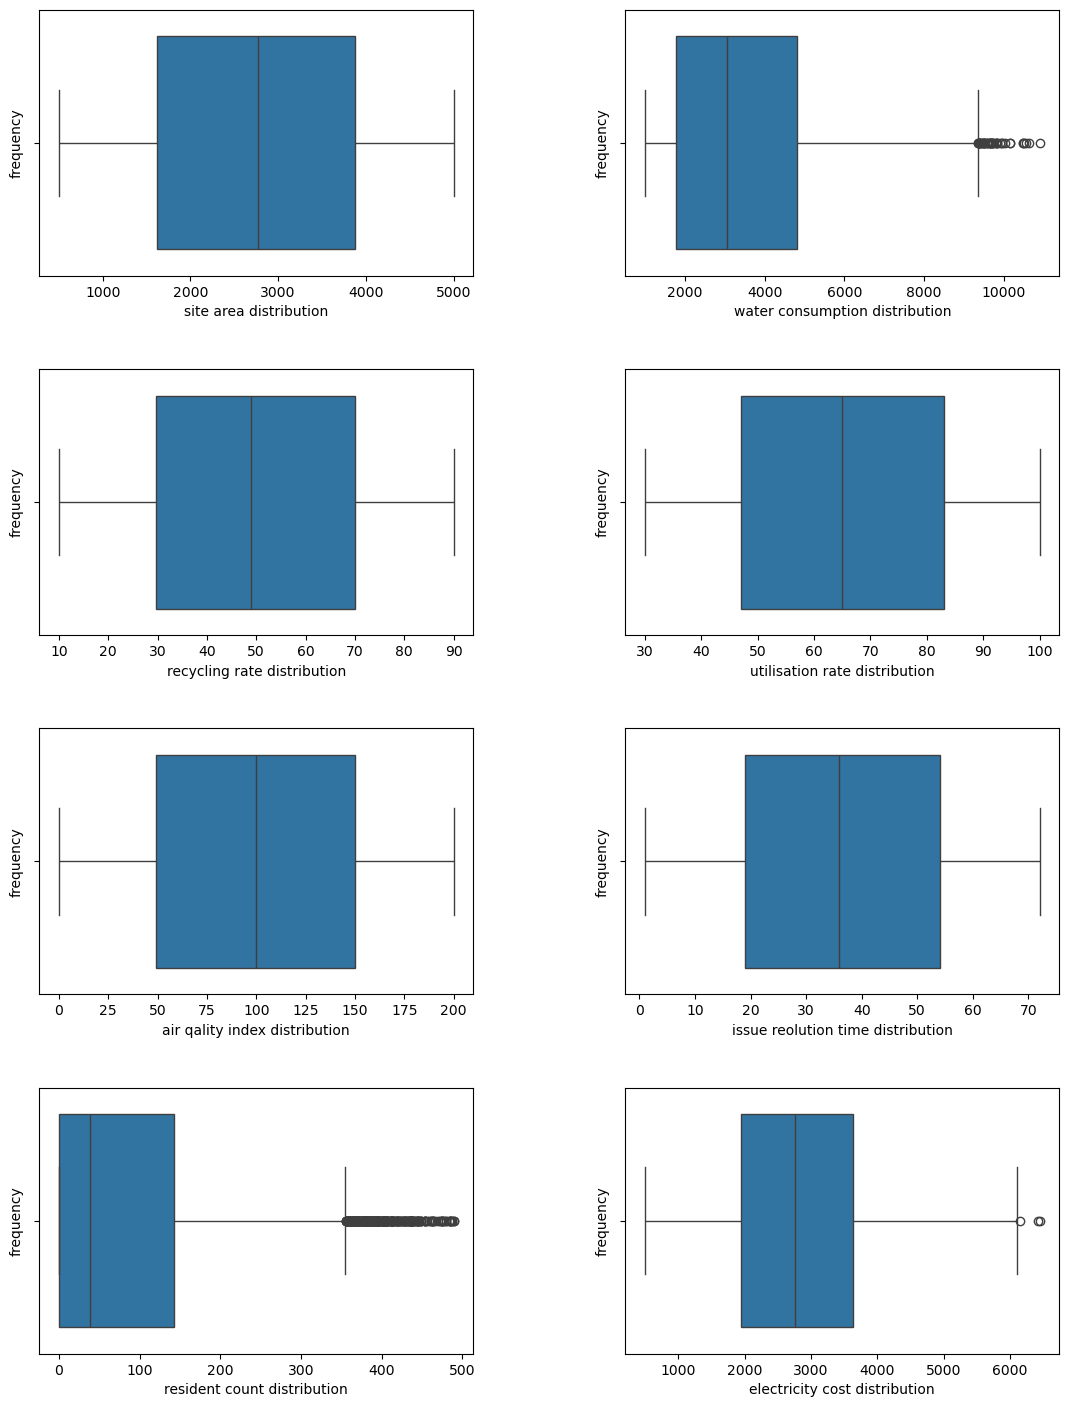

In [ ]:
#Defini tamanho do gráfico
plt.figure(figsize=(12, 16))

#Grafico boxplot com laço nas colunas númericas
for i, col in enumerate(numeric_columns):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.boxplot(data=df_original, x=col)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

Outliers nas colunas:
- ***water consumption***
- ***resident count***
- ***electricity cost***

Tratamento será feito na proxima etapa do notebook, após a divisão dos dados, para evitar data leakage (vazamento de dados). Por exemplo:

- Se você calcula limites de outliers com base em todo o conjunto de dados, está usando informações do conjunto de teste na preparação do modelo.
- Isso pode levar a resultados irreais, onde o modelo parece melhor do que realmente é.

### 2.2 - Histplot

Objetivo:
- Entender a forma da distribuição dos dados
- Observar a frequência
- Detectar outliers
- Comparar distribuição

In [ ]:
#Defini tamanho do gráfico
plt.figure(figsize=(12, 16))

#Grafico boxplot com laço nas colunas númericas
for i, col in enumerate(numeric_columns):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.histplot(data=df_original, x=col, kde=True)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()